In [1]:
import utils
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import os
import sys

In [2]:
#create two dataframes for the two cancer types
df_topology = pd.read_excel('../data/topology.xlsx')
df_topology = df_topology.rename(columns={'Unnamed: 0': 'Patient'})
df_topology ['Patient'] = df_topology ['Patient'].str.replace('.txt$', '', regex=True)
df_filtered_primary = df_topology[df_topology['Patient'].isin(utils.list_primary)]
df_filtered_recurrent = df_topology[df_topology['Patient'].isin(utils.list_recurrent)]

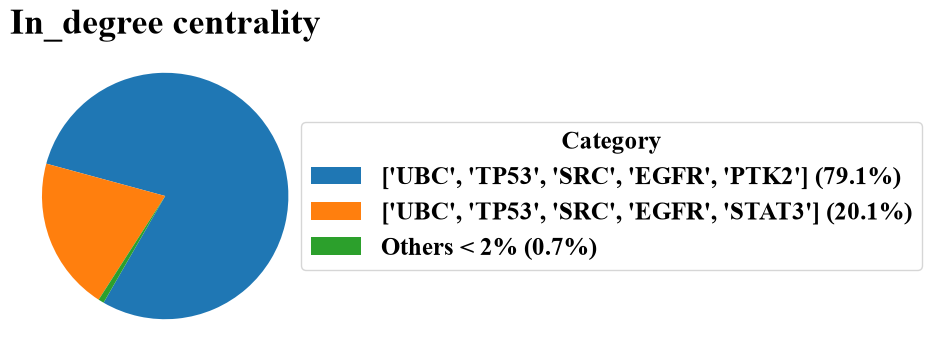

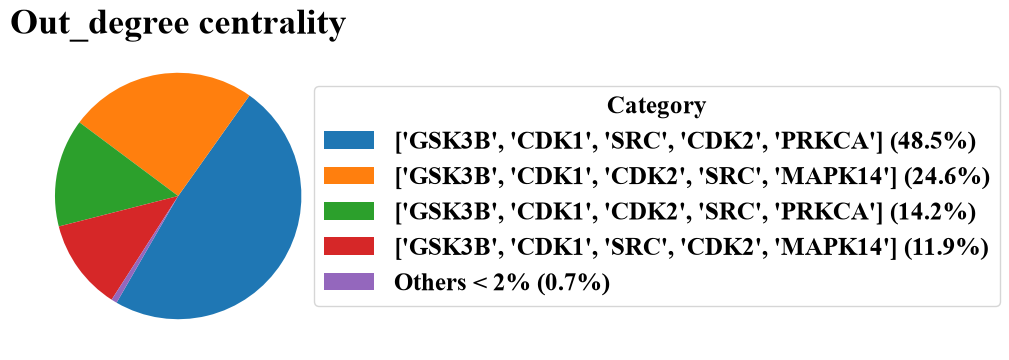

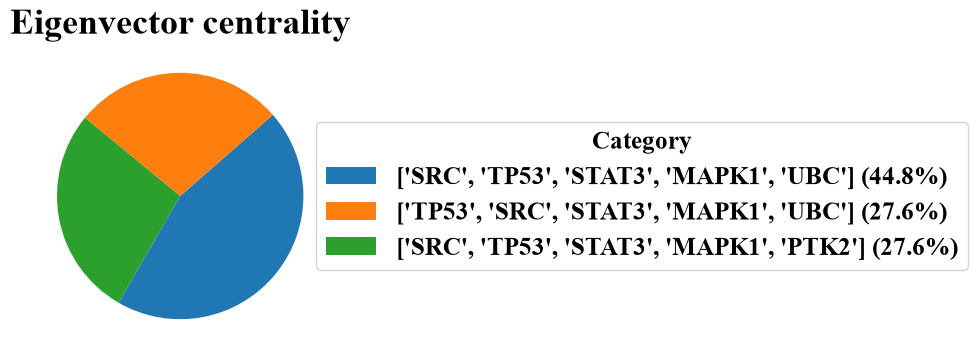

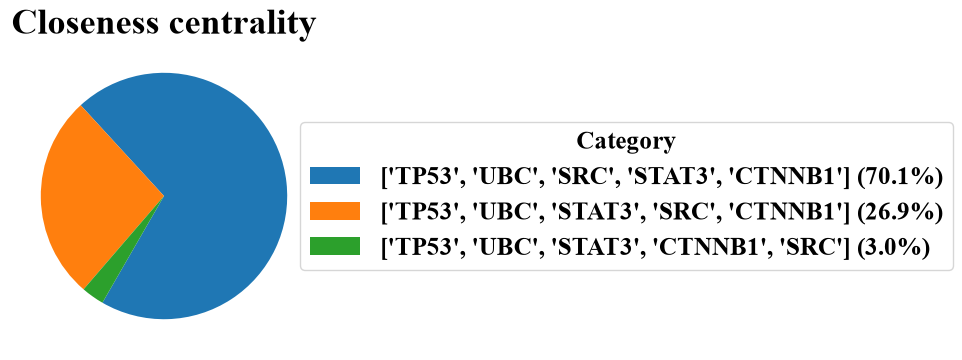

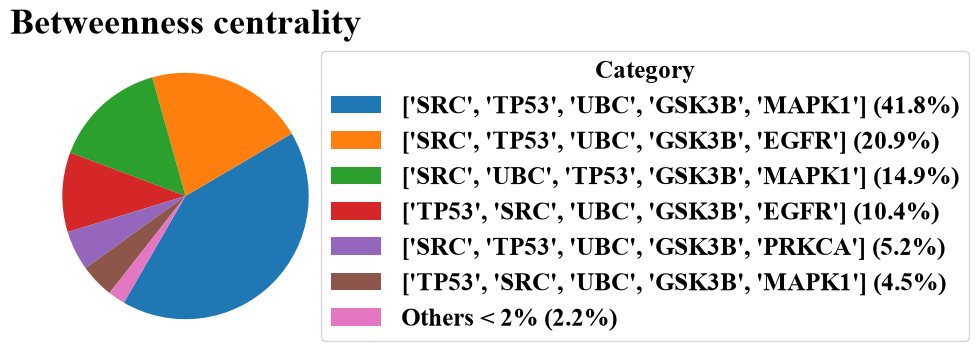

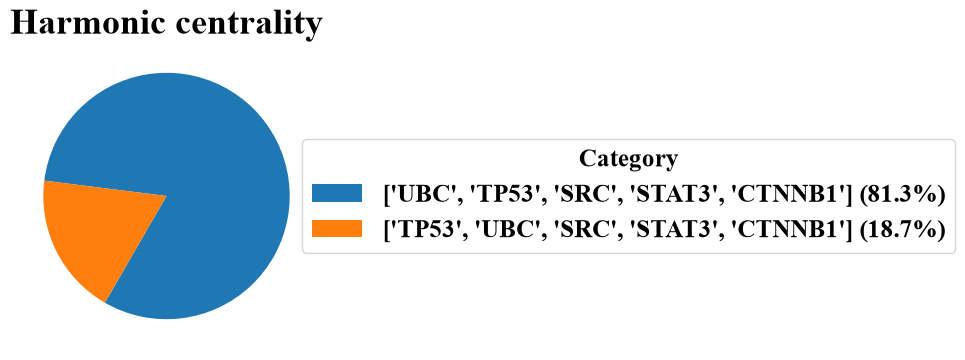

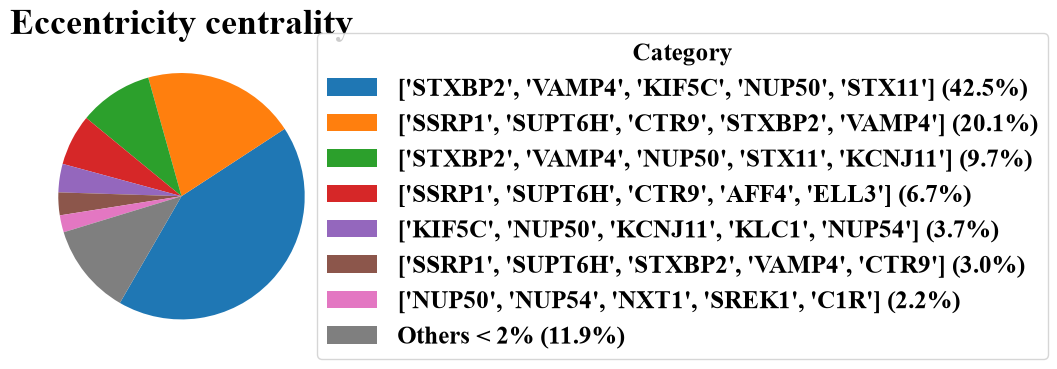

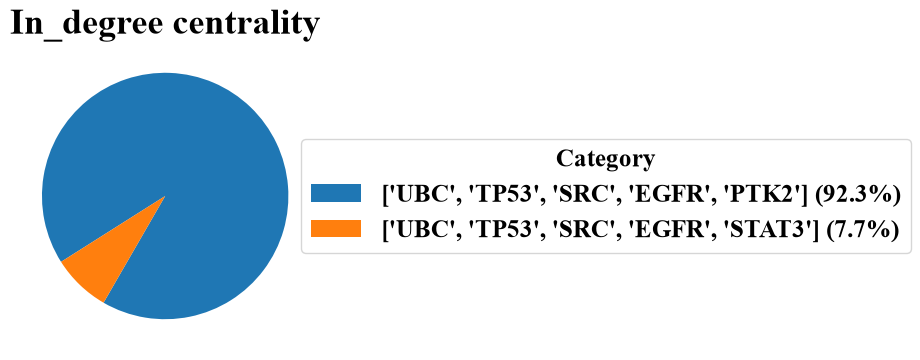

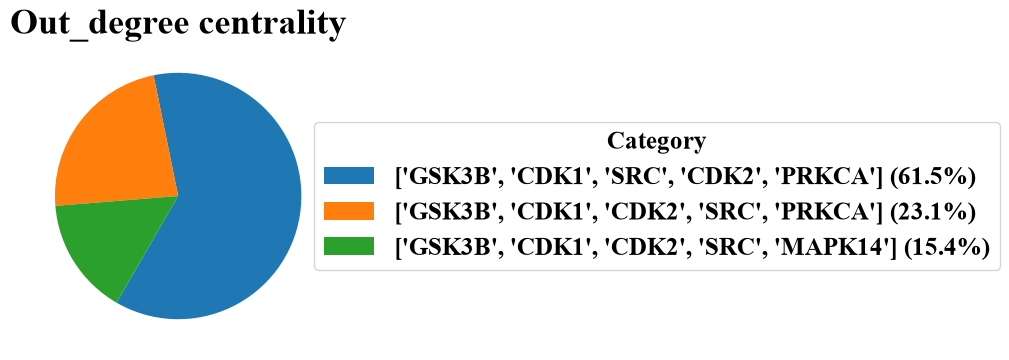

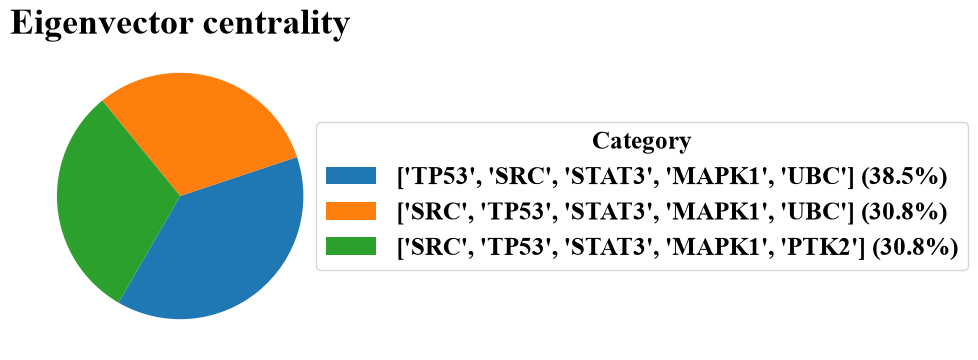

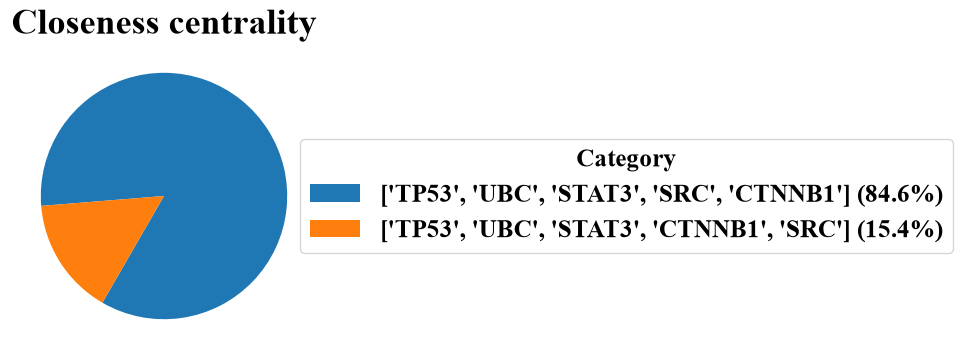

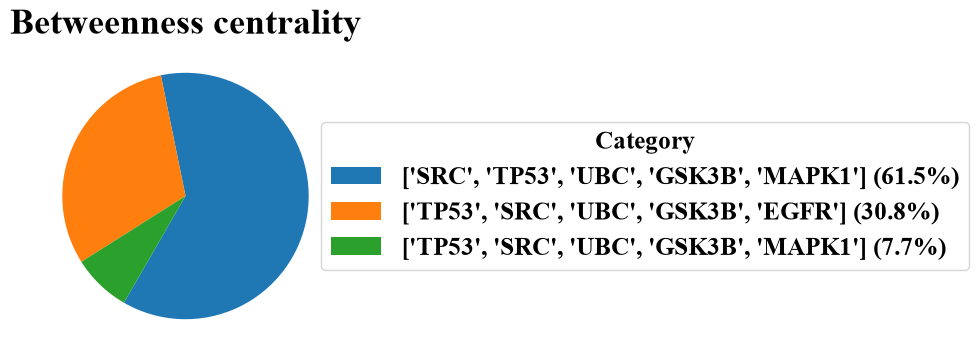

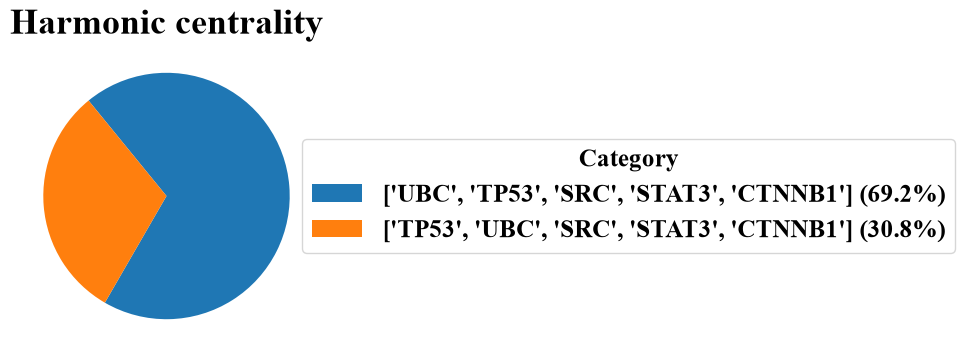

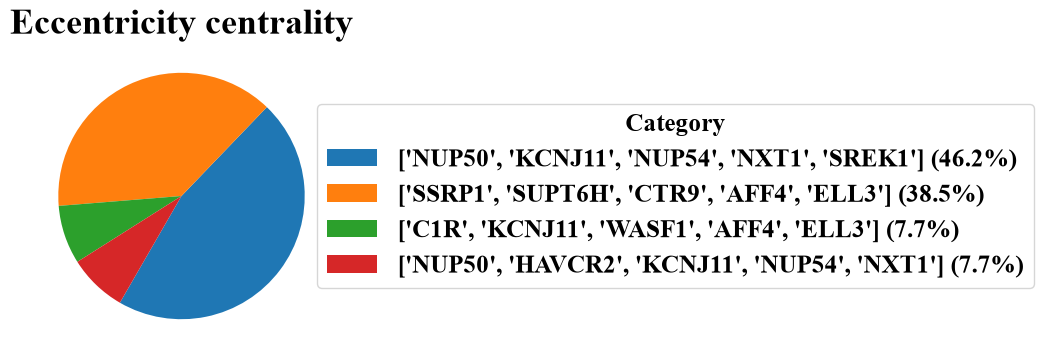

In [3]:
#plot pie charts for in-degree, out-degree, eigenvector, closeness,betweenness, harmonic and eccentricity
def plot_centrality(df_topology,centrality,my_categ):
    counts = df_topology[centrality].value_counts()
    threshold = 0.02

    total = counts.sum()
    fractions = counts / total

    small = counts[fractions < threshold].sum()
    large = counts[fractions >= threshold]

    if small > 0:
        large['Others < 2%'] = small

    counts_filtered = large

    values = counts_filtered.values
    labels = counts_filtered.index
    total = values.sum()

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 18,
        "font.weight": "bold"
    })

    fig, ax = plt.subplots(figsize=(8,4))
    fig.patch.set_alpha(1.0)
    ax.patch.set_alpha(1.0)

    wedges, texts = ax.pie(values, startangle=240, textprops={'color': 'white', 'weight': 'bold'}, wedgeprops={'linewidth': 0, 'alpha': 1.0})
    for wedge in wedges:
        wedge.set_alpha(None)

    percentages = [f'{(value / total) * 100:.1f}%' for value in values]

    ax.legend(
        handles=wedges,
        labels=[f'{label} ({percent})' for label, percent in zip(labels, percentages)],
        loc='center left',
        bbox_to_anchor=(0.9, 0.5),
        title='Category',
        prop={'family': 'Times New Roman', 'size': 18}
    )

    string=centrality.capitalize()+" centrality"
    ax.set_title(string, fontsize=26, fontfamily='Times New Roman', fontweight='bold')
    plt.ylabel('') 

    save_path = Path("../data/fig_centr")
    save_path.mkdir(parents=True, exist_ok=True)

    with open(os.devnull, 'w') as devnull:
        old_stderr = sys.stderr
        sys.stderr = devnull
        plt.savefig(str(save_path) + "/" + my_categ + "_" + centrality + ".eps", format="eps", dpi=500, transparent=False, bbox_inches='tight')
        sys.stderr = old_stderr
        
    plt.show()
   
plot_centrality(df_filtered_primary,"in_degree","primary")
plot_centrality(df_filtered_primary,"out_degree","primary")
plot_centrality(df_filtered_primary,"eigenvector","primary")
plot_centrality(df_filtered_primary,"closeness","primary")
plot_centrality(df_filtered_primary,"betweenness","primary")
plot_centrality(df_filtered_primary,"harmonic","primary")
plot_centrality(df_filtered_primary,"eccentricity","primary")

plot_centrality(df_filtered_recurrent,"in_degree","recurrent")
plot_centrality(df_filtered_recurrent,"out_degree","recurrent")
plot_centrality(df_filtered_recurrent,"eigenvector","recurrent")
plot_centrality(df_filtered_recurrent,"closeness","recurrent")
plot_centrality(df_filtered_recurrent,"betweenness","recurrent")
plot_centrality(df_filtered_recurrent,"harmonic","recurrent")
plot_centrality(df_filtered_recurrent,"eccentricity","recurrent")

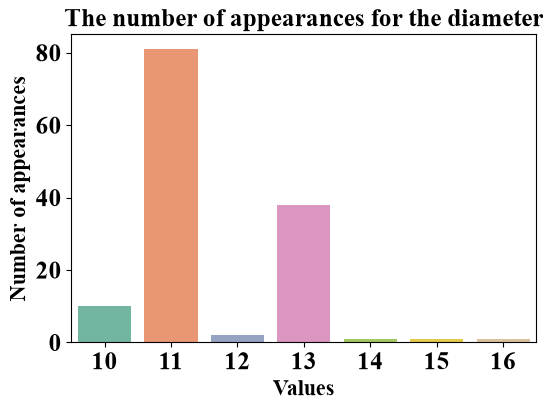

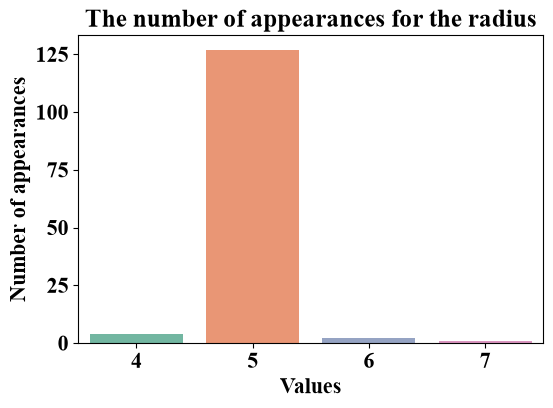

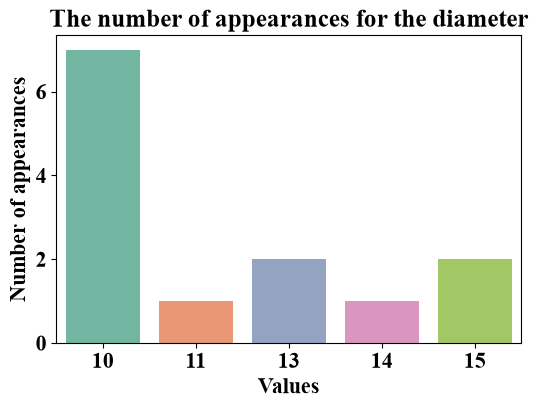

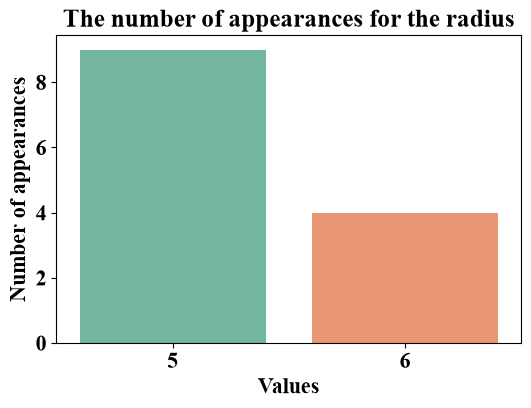

In [4]:
#make boxplots for diameter and radius
def plot_boxplot(df_filtered,topology,my_list):
    fig, ax = plt.subplots(figsize=(6,4))
    sns.countplot(x=topology, hue=topology,data=df_filtered, palette="Set2",legend=False)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['font.size'] = 16
    plt.rcParams['font.weight'] = 'bold'
    #sns.boxplot(x=df_filtered[topology], data=df_filtered, palette="Set2")
    string="The number of appearances for the "+ topology
    plt.title(string,fontsize=18, fontfamily='Times New Roman', fontweight='bold')
    plt.xlabel("Values",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
    plt.ylabel("Number of appearances",fontsize=16, fontfamily='Times New Roman', fontweight='bold') 

    save_path = Path("../data/fig_centr")
    save_path.mkdir(parents=True, exist_ok=True)    
    plt.savefig(str(save_path)+"/"+my_list+"_"+topology+".eps", format="eps",dpi=500, bbox_inches='tight')
    plt.show()

plot_boxplot(df_filtered_primary,"diameter","primary")
plot_boxplot(df_filtered_primary,"radius","primary")

plot_boxplot(df_filtered_recurrent,"diameter","recurrent")
plot_boxplot(df_filtered_recurrent,"radius","recurrent")

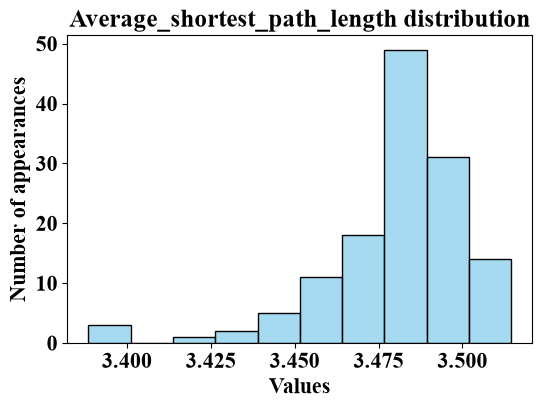

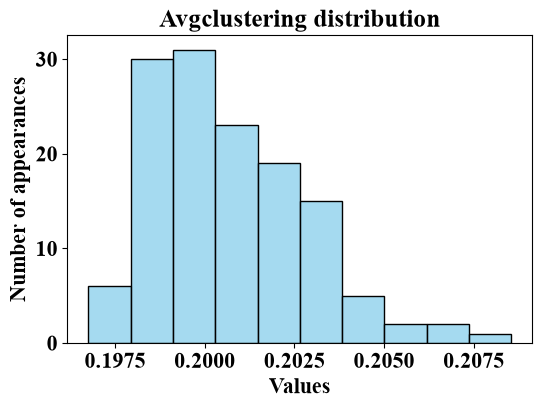

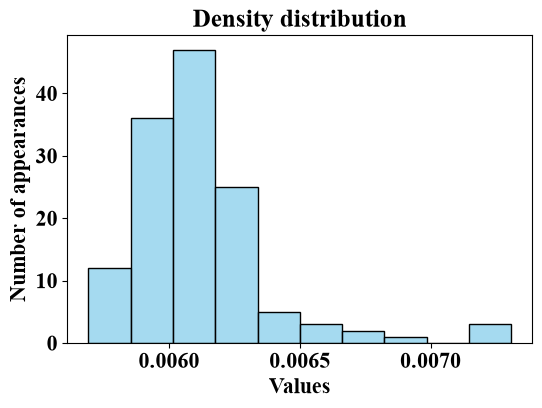

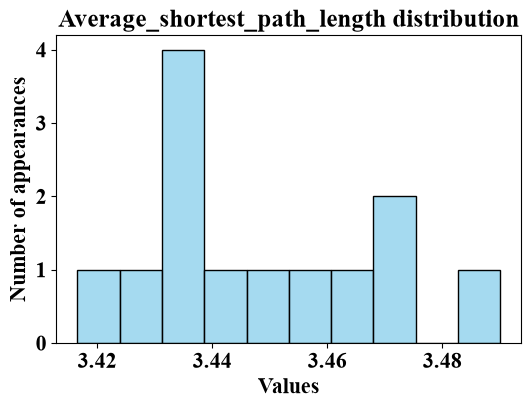

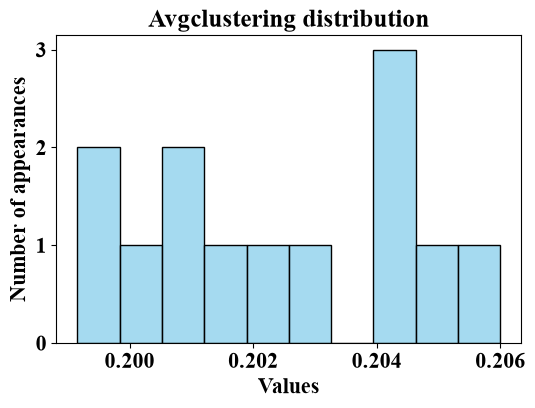

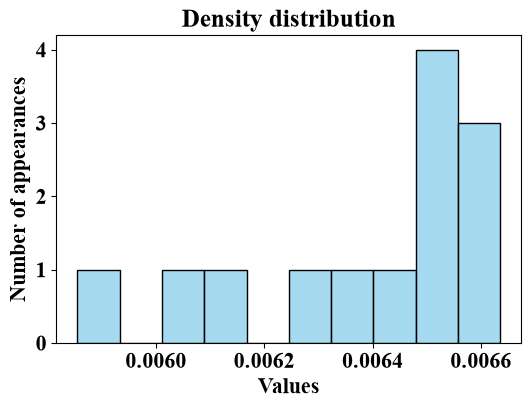

In [5]:
#plot histograms for average shortest path length, average clustering and density
def plot_histogram(df_filtered, topology, my_list):
    fig, ax = plt.subplots(figsize=(6,4))
    sns.histplot(df_filtered[topology], bins=10, color='skyblue')
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['font.size'] = 16
    plt.rcParams['font.weight'] = 'bold'
    string=topology.capitalize()+" distribution"
    plt.title(string, fontsize=18, fontfamily='Times New Roman', fontweight='bold')
    plt.xlabel("Values", fontsize=16, fontfamily='Times New Roman', fontweight='bold')
    plt.ylabel("Number of appearances",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
    
    save_path = Path("../data/fig_centr")
    save_path.mkdir(parents=True, exist_ok=True) 
    with open(os.devnull, 'w') as devnull:
        old_stderr = sys.stderr
        sys.stderr = devnull
        plt.savefig(str(save_path)+"/"+my_list+"_"+topology+".eps", format="eps",dpi=500, bbox_inches='tight')
        sys.stderr = old_stderr
        
    plt.show()

plot_histogram(df_filtered_primary,"average_shortest_path_length","primary")
plot_histogram(df_filtered_primary,"avgclustering","primary")
plot_histogram(df_filtered_primary,"density","primary")

plot_histogram(df_filtered_recurrent,"average_shortest_path_length","recurrent")
plot_histogram(df_filtered_recurrent,"avgclustering","recurrent")
plot_histogram(df_filtered_recurrent,"density","recurrent")